In [254]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import lseg.data as ld
from lseg.data.discovery import Chain
from lseg.data.content import esg


In [ ]:
# ========== CONFIG ==========
INDEX_CHAIN = "0#.SPX"   # S&P 500 chain
INDEX_RIC   = ".SPX"     # benchmark index
START_DATE  = "2015-01-01"
END_DATE    = "2025-01-01"
N_SELECT    = 50         # number of lowest emitters
APP_KEY_PATH = "C:/Users/JanderM/lseg-data.config.json"
# ============================

ld.open_session(name="desktop.workspace", config_name=APP_KEY_PATH)



<lseg.data.session.Definition object at 0x1d2165bf880 {name='workspace'}>

# 1 Data Extraction

In [ ]:
# ---- Get Constituents ----

cons_file = "constituents.csv"
if os.path.exists(cons_file):
    tickers = pd.read_csv(cons_file)["RIC"].tolist()
else:
    cons = Chain(INDEX_CHAIN)
    tickers = cons.constituents
    pd.DataFrame({"RIC": tickers}).to_csv(cons_file, index=False)

print("Number of constituents:", len(tickers))
print("Sample tickers:", tickers)



Number of constituents: 503
Sample tickers: ['A.N', 'AAPL.OQ', 'ABBV.N', 'ABNB.OQ', 'ABT.N', 'ACGL.OQ', 'ACN.N', 'ADBE.OQ', 'ADI.OQ', 'ADM.N', 'ADP.OQ', 'ADSK.OQ', 'AEE.N', 'AEP.OQ', 'AES.N', 'AFL.N', 'AIG.N', 'AIZ.N', 'AJG.N', 'AKAM.OQ', 'ALB.N', 'ALGN.OQ', 'ALL.N', 'ALLE.N', 'AMAT.OQ', 'AMCR.N', 'AMD.OQ', 'AME.N', 'AMGN.OQ', 'AMP.N', 'AMT.N', 'AMZN.OQ', 'ANET.N', 'AON.N', 'AOS.N', 'APA.OQ', 'APD.N', 'APH.N', 'APO.N', 'APTV.N', 'ARE.N', 'ATO.N', 'AVB.N', 'AVGO.OQ', 'AVY.N', 'AWK.N', 'AXON.OQ', 'AXP.N', 'AZO.N', 'BA.N', 'BAC.N', 'BALL.N', 'BAX.N', 'BBY.N', 'BDX.N', 'BEN.N', 'BFb.N', 'BG.N', 'BIIB.OQ', 'BK.N', 'BKNG.OQ', 'BKR.OQ', 'BLDR.N', 'BLK.N', 'BMY.N', 'BR.N', 'BRKb.N', 'BRO.N', 'BSX.N', 'BX.N', 'BXP.N', 'C.N', 'CAG.N', 'CAH.N', 'CARR.N', 'CAT.N', 'CB.N', 'CBOE.Z', 'CBRE.N', 'CCI.N', 'CCL.N', 'CDNS.OQ', 'CDW.OQ', 'CEG.OQ', 'CF.N', 'CFG.N', 'CHD.N', 'CHRW.OQ', 'CHTR.OQ', 'CI.N', 'CINF.OQ', 'CL.N', 'CLX.N', 'CMCSA.OQ', 'CME.OQ', 'CMG.N', 'CMI.N', 'CMS.N', 'CNC.N', 'CNP.N', 'COF.N', 

In [ ]:
# ---- Get Carbon Emissions Data ----
carbon_file = "sp500_carbon_emissions_snapshots.csv"

if os.path.exists(carbon_file):
    print(f"Loading cached carbon emissions data from {carbon_file}...")
    carbon_df = pd.read_csv(carbon_file)
else:
    print("Fetching ESG snapshot data from LSEG...")
    carbon_df = ld.get_data(universe=tickers, fields=["TR.CO2EmissionTotal "])
    carbon_df.to_csv(carbon_file, index=False)
    print(f"Saved carrbon emissions data to {carbon_file}")

print(carbon_df.head())


Loading cached carbon emissions data from sp500_carbon_emissions_snapshots.csv...
  Instrument  CO2 Equivalent Emissions Total
0        A.N                         68619.0
1    AAPL.OQ                       1279700.0
2     ABBV.N                        541214.0
3    ABNB.OQ                          7363.0
4      ABT.N                        981000.0


In [ ]:
# select N_SELECT lowest emitters
low_emitters = carbon_df.sort_values("CO2 Equivalent Emissions Total").head(N_SELECT)["Instrument"].tolist()
print("Selected assets:", low_emitters[:10], "...")
print("Number of selected assets:", len(low_emitters))


Selected assets: ['CPAY.N', 'O.N', 'MKTX.OQ', 'EG.N', 'DDOG.OQ', 'VICI.N', 'BKNG.OQ', 'PLTR.OQ', 'XYZ.N', 'MTCH.OQ'] ...
Number of selected assets: 50


In [ ]:
# ---- Get Price Data ----
prices_file = "prices.csv"
if os.path.exists(prices_file):
    prices = pd.read_csv(prices_file, index_col="Date", parse_dates=True)
else:
    prices = ld.get_history(
        universe=low_emitters,
        fields=["TR.PriceClose"],
        start=START_DATE,
        end=END_DATE,
        interval="daily"
    )
    prices.to_csv(prices_file, index=True)



In [260]:
prices.head()

,CPAY.N,O.N,MKTX.OQ,EG.N,DDOG.OQ,VICI.N,BKNG.OQ,PLTR.OQ,XYZ.N,MTCH.OQ,DAY.N,INVH.N,PAYX.OQ,GL.N,KKR.N,VRSK.OQ,MSCI.N,ABNB.OQ,MCO.N,PLD.N,PTC.OQ,ACGL.OQ,TYL.N,DECK.N,ADSK.OQ,HAS.OQ,IVZ.N,CME.OQ,APO.N,AFL.N,IT.N,BX.N,FFIV.OQ,FTNT.OQ,PODD.OQ,GEN.OQ,FDS.N,CBOE.Z,AIZ.N,CSGP.OQ,ZBRA.OQ,TRMB.OQ,INCY.OQ,ENPH.OQ,TTWO.OQ,TPR.N,SYF.N,HIG.N,PANW.OQ,EXPE.OQ
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,150.26,47.0827,70.35,168.82,NaN,NaN,1142.06,NaN,NaN,NaN,NaN,NaN,46.24,54.16,23.49,63.97,47.69,NaN,95.89,43.43,36.350,18.5393,107.85,14.9567,59.53,54.97,39.14,77.2058,23.57,30.540,83.60,33.4695,130.33,6.158,45.18,11.9029,140.59,63.360,67.77,18.013,77.43,26.910,73.76,14.21,28.095,37.31,29.48,41.79,20.2366,85.76
2015-01-05,143.78,48.0511,68.99,167.91,NaN,NaN,1097.58,NaN,NaN,NaN,NaN,NaN,46.32,53.19,23.34,63.14,47.24,NaN,94.01,43.40,35.360,18.4284,105.97,14.8434,58.66,55.13,38.00,77.6438,22.85,29.740,82.10,32.9792,129.76,6.104,45.09,11.7354,138.39,65.380,66.25,17.655,76.34,26.030,74.22,13.88,27.620,36.73,29.25,40.91,20.6216,84.20
2015-01-06,142.25,48.6805,67.66,168.97,NaN,NaN,1079.96,NaN,NaN,NaN,NaN,NaN,45.99,52.47,23.11,62.92,48.61,NaN,93.02,43.55,35.075,18.4696,104.91,14.5850,57.50,54.41,37.21,76.4569,22.13,29.475,81.35,32.3417,126.73,5.990,43.49,11.5540,137.66,66.060,65.33,17.583,75.79,25.655,71.49,12.94,27.930,36.30,28.85,40.24,20.3083,84.17
2015-01-07,143.21,49.4746,68.27,170.11,NaN,NaN,1069.57,NaN,NaN,NaN,NaN,NaN,46.83,52.53,23.54,62.96,49.72,NaN,94.44,44.21,35.220,18.5774,106.03,15.0584,57.38,54.67,37.70,77.3460,22.78,29.660,82.60,32.8026,128.35,6.076,44.53,11.6610,138.76,67.180,65.59,17.677,77.72,25.340,74.45,11.40,28.100,37.42,29.20,40.62,20.9216,84.17
2015-01-08,146.12,48.1673,71.70,174.96,NaN,NaN,1082.85,NaN,NaN,NaN,NaN,NaN,47.56,53.34,23.40,63.59,51.22,NaN,95.36,44.22,35.750,18.9007,109.20,15.6684,58.80,55.00,38.36,77.7051,23.82,29.950,83.43,33.0576,129.65,6.242,40.52,11.8750,140.47,66.495,66.57,18.004,79.38,25.670,73.21,11.73,28.460,38.37,29.98,41.06,21.2016,87.89


In [261]:
# Keep only assets with full 10Y data (no NA)
valid_assets = prices.dropna(axis=1).columns
prices = prices[valid_assets]
returns = prices.pct_change().dropna()

print("Number of valid assets:", len(valid_assets))
print(returns.head())

Number of valid assets: 42
            CPAY.N     O.N  MKTX.OQ    EG.N  BKNG.OQ  PAYX.OQ    GL.N   KKR.N  \
Date                                                                            
2015-01-05 -0.0431  0.0206  -0.0193 -0.0054  -0.0389   0.0017 -0.0179 -0.0064   
2015-01-06 -0.0106  0.0131  -0.0193  0.0063  -0.0161  -0.0071 -0.0135 -0.0099   
2015-01-07  0.0067  0.0163   0.0090  0.0067  -0.0096   0.0183  0.0011  0.0186   
2015-01-08  0.0203 -0.0264   0.0502  0.0285   0.0124   0.0156  0.0154 -0.0059   
2015-01-09 -0.0176  0.0119  -0.0026 -0.0192  -0.0285  -0.0088 -0.0144  0.0145   

            VRSK.OQ  MSCI.N   MCO.N   PLD.N  PTC.OQ  ACGL.OQ   TYL.N  DECK.N  \
Date                                                                           
2015-01-05  -0.0130 -0.0094 -0.0196 -0.0007 -0.0272  -0.0060 -0.0174 -0.0076   
2015-01-06  -0.0035  0.0290 -0.0105  0.0035 -0.0081   0.0022 -0.0100 -0.0174   
2015-01-07   0.0006  0.0228  0.0153  0.0152  0.0041   0.0058  0.0107  0.0325   
2015-

In [ ]:
# ---- Baseline (S&P 500 Index) Mean & Covariance ----

sp500_file = "sp500_prices.csv"
sp500_ticker = [INDEX_RIC]  # e.g., [".SPX"]

if os.path.exists(sp500_file):
    sp500_prices = pd.read_csv(sp500_file, parse_dates=True)
else:
    print("Fetching S&P 500 index price history...")
    sp500_prices = ld.get_history(
        universe=sp500_ticker,
        fields=["TR.PriceClose"],
        start=START_DATE,
        end=END_DATE,
        interval="daily"
    )
    sp500_prices.to_csv(sp500_file, index=True)

print("S&P 500 prices loaded. Sample data:")
print(sp500_prices.head())

S&P 500 prices loaded. Sample data:
         Date  Price Close
0  2014-12-31      2058.90
1  2015-01-02      2058.20
2  2015-01-05      2020.58
3  2015-01-06      2002.61
4  2015-01-07      2025.90


In [263]:
# set Date to datetime and index
sp500_prices['Date'] = pd.to_datetime(sp500_prices['Date'])
sp500_prices.set_index('Date', inplace=True)

sp500_prices

,Price Close
Date,
2014-12-31,2058.90
2015-01-02,2058.20
2015-01-05,2020.58
2015-01-06,2002.61
2015-01-07,2025.90
...,...
2024-12-24,6040.04
2024-12-26,6037.59
2024-12-27,5970.84


<Axes: xlabel='Date'>

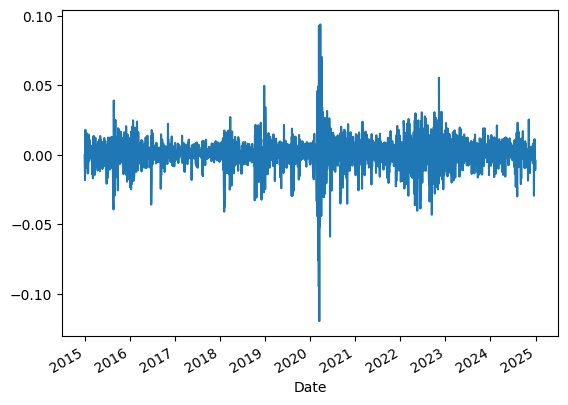

In [264]:
# Compute daily returns
sp500_returns = sp500_prices["Price Close"].pct_change().dropna()

sp500_returns.plot()

In [265]:
# Set Date to datetime index
sp500_returns.index = pd.to_datetime(sp500_returns.index)

# Helper function for annualized stats
def annualized_stats(returns, start, end):
    period = returns.loc[start:end]
    mu = period.mean() * 252
    sigma = period.std() * np.sqrt(252)
    return mu, sigma

# In-sample stats
sp500_mu_15_18, sp500_sigma_15_18 = annualized_stats(sp500_returns, "2015-01-01", "2018-12-31")
sp500_mu_15_22, sp500_sigma_15_22 = annualized_stats(sp500_returns, "2015-01-01", "2022-12-31")

# Out-of-sample stats
sp500_mu_19, sp500_sigma_19 = annualized_stats(sp500_returns, "2019-01-01", "2019-12-31")
sp500_mu_23_24, sp500_sigma_23_24 = annualized_stats(sp500_returns, "2023-01-01", "2024-12-31")

# Print results
print("S&P 500 (2015–2018): μ = {:.2%}, σ = {:.2%}".format(sp500_mu_15_18, sp500_sigma_15_18))
print("S&P 500 (2015–2022): μ = {:.2%}, σ = {:.2%}".format(sp500_mu_15_22, sp500_sigma_15_22))
print("S&P 500 (2019): μ = {:.2%}, σ = {:.2%}".format(sp500_mu_19, sp500_sigma_19))
print("S&P 500 (2023–2024): μ = {:.2%}, σ = {:.2%}".format(sp500_mu_23_24, sp500_sigma_23_24))



S&P 500 (2015–2018): μ = 5.87%, σ = 13.66%
S&P 500 (2015–2022): μ = 9.54%, σ = 18.81%
S&P 500 (2019): μ = 26.16%, σ = 12.46%
S&P 500 (2023–2024): μ = 22.24%, σ = 12.86%


In [266]:
ld.close_session()

# 2 Portfolio Optimization
## 2.1 5 Year Data

In [267]:
# filter returns to first 4 years for in-sample and 5th year for out-of-sample
returns_15_18 = returns.loc["2015":"2018"]
returns_19 = returns.loc["2019"]

returns_15_18

,CPAY.N,O.N,MKTX.OQ,EG.N,BKNG.OQ,PAYX.OQ,GL.N,KKR.N,VRSK.OQ,MSCI.N,MCO.N,PLD.N,PTC.OQ,ACGL.OQ,TYL.N,DECK.N,ADSK.OQ,HAS.OQ,IVZ.N,CME.OQ,APO.N,AFL.N,IT.N,BX.N,FFIV.OQ,FTNT.OQ,PODD.OQ,GEN.OQ,FDS.N,CBOE.Z,AIZ.N,CSGP.OQ,ZBRA.OQ,TRMB.OQ,INCY.OQ,ENPH.OQ,TTWO.OQ,TPR.N,SYF.N,HIG.N,PANW.OQ,EXPE.OQ
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.0431,0.0206,-0.0193,-0.0054,-0.0389,0.0017,-0.0179,-0.0064,-0.0130,-0.0094,-0.0196,-0.0007,-0.0272,-0.0060,-0.0174,-0.0076,-0.0146,0.0029,-0.0291,0.0057,-0.0305,-0.0262,-0.0179,-0.0146,-0.0044,-0.0088,-0.0020,-0.0141,-0.0156,0.0319,-0.0224,-0.0199,-0.0141,-0.0327,0.0062,-0.0232,-0.0169,-0.0155,-0.0078,-0.0211,0.0190,-0.0182
2015-01-06,-0.0106,0.0131,-0.0193,0.0063,-0.0161,-0.0071,-0.0135,-0.0099,-0.0035,0.0290,-0.0105,0.0035,-0.0081,0.0022,-0.0100,-0.0174,-0.0198,-0.0131,-0.0208,-0.0153,-0.0315,-0.0089,-0.0091,-0.0193,-0.0234,-0.0187,-0.0355,-0.0155,-0.0053,0.0104,-0.0139,-0.0041,-0.0072,-0.0144,-0.0368,-0.0677,0.0112,-0.0117,-0.0137,-0.0164,-0.0152,-0.0004
2015-01-07,0.0067,0.0163,0.0090,0.0067,-0.0096,0.0183,0.0011,0.0186,0.0006,0.0228,0.0153,0.0152,0.0041,0.0058,0.0107,0.0325,-0.0021,0.0048,0.0132,0.0116,0.0294,0.0063,0.0154,0.0143,0.0128,0.0144,0.0239,0.0093,0.0080,0.0170,0.0040,0.0053,0.0255,-0.0123,0.0414,-0.1190,0.0061,0.0309,0.0121,0.0094,0.0302,0.0000
2015-01-08,0.0203,-0.0264,0.0502,0.0285,0.0124,0.0156,0.0154,-0.0059,0.0100,0.0302,0.0097,0.0002,0.0150,0.0174,0.0299,0.0405,0.0247,0.0060,0.0175,0.0046,0.0457,0.0098,0.0100,0.0078,0.0101,0.0273,-0.0901,0.0183,0.0123,-0.0102,0.0149,0.0185,0.0214,0.0130,-0.0167,0.0289,0.0128,0.0254,0.0267,0.0108,0.0134,0.0442
2015-01-09,-0.0176,0.0119,-0.0026,-0.0192,-0.0285,-0.0088,-0.0144,0.0145,-0.0079,0.0146,-0.0161,-0.0016,-0.0036,-0.0087,-0.0157,-0.0028,-0.0090,-0.0324,-0.0185,0.0009,0.0021,-0.0212,-0.0038,0.0148,0.0019,-0.0045,0.0190,-0.0067,-0.0078,-0.0074,-0.0035,-0.0158,0.0146,-0.0019,-0.0161,-0.0171,-0.0207,-0.0044,-0.0093,-0.0093,-0.0109,-0.0039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-24,-0.0051,-0.0552,-0.0269,-0.0352,-0.0101,-0.0345,-0.0265,-0.0179,-0.0280,-0.0160,-0.0244,-0.0498,-0.0287,-0.0294,-0.0188,-0.0295,-0.0165,-0.0012,-0.0181,-0.0330,0.0000,-0.0208,-0.0269,0.0165,-0.0288,-0.0050,0.0012,-0.0260,-0.0302,-0.0505,-0.0310,0.0002,-0.0229,-0.0111,-0.0029,-0.0211,-0.0257,-0.0155,-0.0147,-0.0339,-0.0194,-0.0095
2018-12-26,0.0416,0.0438,0.0258,0.0218,0.0535,0.0435,0.0401,0.0503,0.0432,0.0477,0.0564,0.0363,0.0584,0.0452,0.0418,0.0954,0.0643,0.0391,0.0490,0.0323,0.0307,0.0428,0.0434,0.0573,0.0475,0.0467,0.0434,0.0306,0.0477,0.0317,0.0535,0.0516,0.0673,0.0438,0.0602,0.0754,0.0594,0.0492,0.0438,0.0513,0.0688,0.0467
2018-12-27,0.0126,0.0064,0.0067,0.0219,0.0085,0.0137,0.0117,0.0112,0.0156,0.0264,0.0241,0.0005,0.0204,0.0239,0.0097,-0.0006,0.0118,0.0039,0.0140,0.0208,-0.0008,0.0190,-0.0222,-0.0059,0.0205,0.0265,-0.0017,0.0054,0.0132,0.0159,0.0098,0.0034,0.0186,0.0187,0.0052,-0.0180,0.0145,0.0077,0.0121,0.0238,0.0034,0.0015


In [ ]:
# ---- Mean & Covariance ----
mu_15_18 = returns_15_18.mean() * 252   # annualized mean
sigma_15_18 = returns_15_18.cov() * 252 # annualized covariance

print("Mean returns (annualized):")
print(mu_15_18.head())
print("\nCovariance matrix (annualized):")
print(sigma_15_18.head())


Mean returns (annualized):
CPAY.N     0.0890
O.N        0.0850
MKTX.OQ    0.3091
EG.N       0.0822
BKNG.OQ    0.1370
dtype: float64

Covariance matrix (annualized):
         CPAY.N     O.N  MKTX.OQ    EG.N  BKNG.OQ  PAYX.OQ    GL.N   KKR.N  \
CPAY.N   0.0718  0.0062   0.0147  0.0100   0.0280   0.0197  0.0200  0.0320   
O.N      0.0062  0.0395   0.0067  0.0073   0.0048   0.0115  0.0038  0.0034   
MKTX.OQ  0.0147  0.0067   0.0665  0.0129   0.0140   0.0124  0.0140  0.0136   
EG.N     0.0100  0.0073   0.0129  0.0369   0.0115   0.0118  0.0152  0.0147   
BKNG.OQ  0.0280  0.0048   0.0140  0.0115   0.0673   0.0171  0.0173  0.0281   

         VRSK.OQ  MSCI.N   MCO.N   PLD.N  PTC.OQ  ACGL.OQ   TYL.N  DECK.N  \
CPAY.N    0.0191  0.0266  0.0287  0.0174  0.0351   0.0111  0.0277  0.0304   
O.N       0.0091  0.0108  0.0088  0.0257  0.0055   0.0063  0.0076  0.0079   
MKTX.OQ   0.0134  0.0176  0.0210  0.0116  0.0152   0.0100  0.0203  0.0114   
EG.N      0.0094  0.0127  0.0137  0.0110  0.0099   0.0174 

In [269]:
# check for NaNs in mu and sigma
print(mu_15_18.isna().sum())
print(sigma_15_18.isna().sum().sum())


0
0


In [270]:
# check values of mu and sigma
print(mu_15_18.describe())
print(sigma_15_18.iloc[:5, :5])


count    42.0000
mean      0.1274
std       0.1015
min      -0.1762
25%       0.0857
50%       0.1150
75%       0.1753
max       0.3809
dtype: float64
         CPAY.N     O.N  MKTX.OQ    EG.N  BKNG.OQ
CPAY.N   0.0718  0.0062   0.0147  0.0100   0.0280
O.N      0.0062  0.0395   0.0067  0.0073   0.0048
MKTX.OQ  0.0147  0.0067   0.0665  0.0129   0.0140
EG.N     0.0100  0.0073   0.0129  0.0369   0.0115
BKNG.OQ  0.0280  0.0048   0.0140  0.0115   0.0673


In [ ]:
# ---- Compute Efficient Frontier ----

def compute_efficient_frontier(mu, Sigma, n_points=100, solver="SCS"):
    num_assets = len(mu)
    rets, vols, weights = [], [], []

    max_weight = 0.10  # 10% max per asset
    min_weight = 0.01  # no shorting, at least 1% per asset

    # Get min return (global min variance portfolio)
    w_min_var = cp.Variable(num_assets)
    risk = cp.quad_form(w_min_var, Sigma)
    constraints = [
        cp.sum(w_min_var) == 1,
        w_min_var >= 0,
        w_min_var <= max_weight,
        w_min_var >= min_weight   
    ]
    cp.Problem(cp.Minimize(risk), constraints).solve(solver=solver)
    min_ret = float(mu.to_numpy() @ w_min_var.value)

    max_ret = float(mu.max()) * 0.99
    target_returns = np.linspace(min_ret, max_ret, n_points)

    for target in target_returns:
        w = cp.Variable(num_assets)
        risk = cp.quad_form(w, Sigma)
        constraints = [
            cp.sum(w) == 1,
            mu.values @ w >= target,
            w >= 0,
            w <= max_weight,
            w >= min_weight
        ]
        prob = cp.Problem(cp.Minimize(risk), constraints)
        try:
            prob.solve(solver=solver)
            if w.value is not None and prob.status == cp.OPTIMAL:
                weights.append(w.value)
                rets.append(mu.to_numpy() @ w.value)
                vols.append(np.sqrt(w.value.T @ Sigma.to_numpy() @ w.value))
            else:
                weights.append([np.nan] * num_assets)
                rets.append(np.nan)
                vols.append(np.nan)
        except:
            weights.append([np.nan] * num_assets)
            rets.append(np.nan)
            vols.append(np.nan)

    return np.array(vols), np.array(rets), np.array(weights)


vols_15_18, rets_15_18, weights_15_18 = compute_efficient_frontier(mu_15_18, sigma_15_18)


In [272]:
mu_19 = returns_19.mean() * 252   # annualized mean
sigma_19 = returns_19.cov() * 252 # annualized covariance


# Evaluate performance on test data
rets_19 = weights_15_18 @ mu_19 # shape (50,)
vols_19 = np.sqrt(np.einsum('ij,ji->i', weights_15_18 @ sigma_19.values, weights_15_18.T))


In [273]:
# Equal weight portfolio
n_assets = len(mu_15_18)
w_equal = np.ones(n_assets) / n_assets

# In-sample performance (2015–2019)
equal_mu_15_18 = float(mu_15_18.to_numpy() @ w_equal)
equal_sigma_15_18 = float(np.sqrt(w_equal.T @ sigma_15_18.to_numpy() @ w_equal))

# Out-of-sample performance (2020)
equal_mu_19 = float(mu_19.to_numpy() @ w_equal)
equal_sigma_19 = float(np.sqrt(w_equal.T @ sigma_19.to_numpy() @ w_equal))


C:\Users\JanderM\AppData\Local\Temp\ipykernel_21376\188941251.py:10:UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "kx" (-> color='k'). The keyword argument will take precedence.
C:\Users\JanderM\AppData\Local\Temp\ipykernel_21376\188941251.py:11:UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "kx" (-> color='k'). The keyword argument will take precedence.


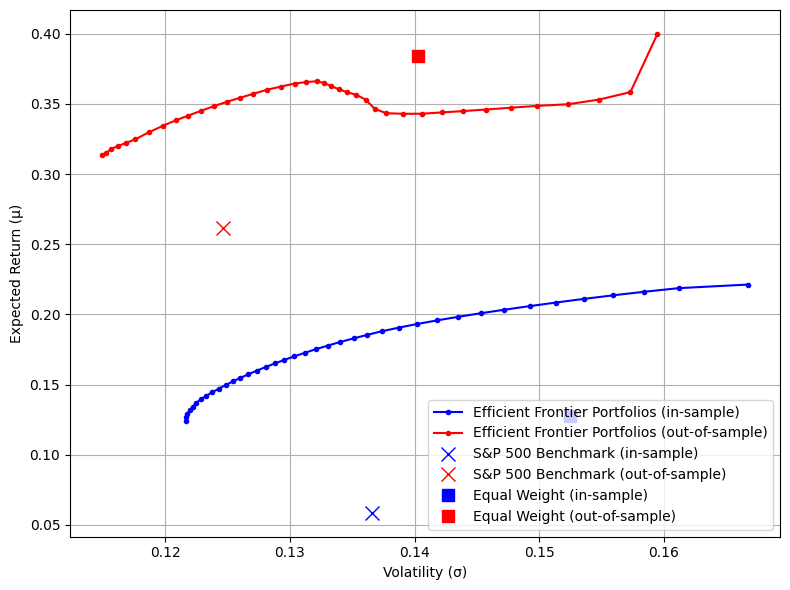

In [283]:
plt.figure(figsize=(8,6))

# Efficient frontier (in-sample)
plt.plot(vols_15_18, rets_15_18, "b.-", label="Efficient Frontier Portfolios (in-sample)")

# Out-of-sample frontier performance
plt.plot(vols_19, rets_19, "r.-", label="Efficient Frontier Portfolios (out-of-sample)")

# Benchmark (S&P500)
plt.plot(sp500_sigma_15_18, sp500_mu_15_18, "kx", color="b", markersize=10, label="S&P 500 Benchmark (in-sample)")
plt.plot(sp500_sigma_19, sp500_mu_19, "kx", color="r", markersize=10, label="S&P 500 Benchmark (out-of-sample)")

# Equal weight portfolios
plt.plot(equal_sigma_15_18, equal_mu_15_18, "bs", markersize=8, label="Equal Weight (in-sample)")
plt.plot(equal_sigma_19, equal_mu_19, "rs", markersize=8, label="Equal Weight (out-of-sample)")

# Labels and formatting
plt.xlabel("Volatility (σ)")
plt.ylabel("Expected Return (μ)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [275]:
# get number of portfolios with valid solutions
valid_portfolios = np.sum(~np.isnan(rets_15_18))

# show portfolio composition of efficient portfolio with same volatility as S&P 500
target_vol = sp500_sigma_15_18
target_weights = weights_15_18[:valid_portfolios][np.argmin(np.abs(vols_15_18[:valid_portfolios] - target_vol))]

# ---- In-Sample Performance (2015–2018) ----
print("In-sample performance (2015–2018):")

# Target portfolio
target_return = mu_15_18 @ target_weights
target_volatility = np.sqrt(target_weights.T @ sigma_15_18.values @ target_weights)
print(f"• Target portfolio return: {target_return:.2%}")
print(f"  Target portfolio volatility: {target_volatility:.2%}")

# S&P 500 Benchmark
print(f"• S&P 500 benchmark return: {sp500_mu_15_18:.2%}")
print(f"  S&P 500 benchmark volatility: {sp500_sigma_15_18:.2%}")

# Equal Weight Portfolio
print(f"• Equal weight portfolio return: {equal_mu_15_18:.2%}")
print(f"  Equal weight portfolio volatility: {equal_sigma_15_18:.2%}")

# ---- Out-of-Sample Performance (2019) ----
print("\nOut-of-sample performance (2019):")

# Target portfolio
out_of_sample_return = target_weights @ mu_19
out_of_sample_volatility = np.sqrt(target_weights.T @ sigma_19.values @ target_weights)
print(f"• Target portfolio return: {out_of_sample_return:.2%}")
print(f"  Target portfolio volatility: {out_of_sample_volatility:.2%}")

# S&P 500 Benchmark
print(f"• S&P 500 benchmark return: {sp500_mu_19:.2%}")
print(f"  S&P 500 benchmark volatility: {sp500_sigma_19:.2%}")

# Equal Weight Portfolio
print(f"• Equal weight portfolio return: {equal_mu_19:.2%}")
print(f"  Equal weight portfolio volatility: {equal_sigma_19:.2%}")


# print portfolio composition of target portfolio
print("\nPortfolio composition for target volatility (S&P 500):")
target_weights_df = pd.DataFrame({"Ticker": returns.columns,
                                  "Weight": target_weights})
target_weights_df

In-sample performance (2015–2018):
• Target portfolio return: 18.55%
  Target portfolio volatility: 13.62%
• S&P 500 benchmark return: 5.87%
  S&P 500 benchmark volatility: 13.66%
• Equal weight portfolio return: 12.74%
  Equal weight portfolio volatility: 15.24%

Out-of-sample performance (2019):
• Target portfolio return: 35.63%
  Target portfolio volatility: 13.53%
• S&P 500 benchmark return: 26.16%
  S&P 500 benchmark volatility: 12.46%
• Equal weight portfolio return: 38.39%
  Equal weight portfolio volatility: 14.03%

Portfolio composition for target volatility (S&P 500):


,Ticker,Weight
0,CPAY.N,0.0100
1,O.N,0.1000
2,MKTX.OQ,0.1000
3,EG.N,0.0100
4,BKNG.OQ,0.0100
5,PAYX.OQ,0.0100
6,GL.N,0.0100
7,KKR.N,0.0100
8,VRSK.OQ,0.0136
9,MSCI.N,0.1000


## 2.2 10 Year Data

In [276]:
# In-sample: 2015–2022
returns_15_22 = returns.loc["2015":"2022"]

# Out-of-sample: 2023–2024
returns_23_24 = returns.loc["2023":"2024"]

In [277]:
# Step 5: Mean & Covariance
mu_15_22 = returns_15_22.mean() * 252
sigma_15_22 = returns_15_22.cov() * 252

# Efficient frontier
vols_15_22, rets_15_22, weights_15_22 = compute_efficient_frontier(mu_15_22, sigma_15_22)

# Out-of-sample stats
mu_23_24 = returns_23_24.mean() * 252
sigma_23_24 = returns_23_24.cov() * 252

rets_23_24 = weights_15_22 @ mu_23_24
vols_23_24 = np.sqrt(np.einsum('ij,jk,ik->i', weights_15_22, sigma_23_24.values, weights_15_22))


In [278]:
len(rets_23_24), len(vols_23_24)

(100, 100)

In [279]:
# Equal weight portfolio
n_assets = len(mu_15_22)
w_equal = np.ones(n_assets) / n_assets

# In-sample (2015–2022)
equal_mu_15_22 = float(mu_15_22.to_numpy() @ w_equal)
equal_sigma_15_22 = float(np.sqrt(w_equal.T @ sigma_15_22.to_numpy() @ w_equal))

# Out-of-sample (2023–2024)
equal_mu_23_24 = float(mu_23_24.to_numpy() @ w_equal)
equal_sigma_23_24 = float(np.sqrt(w_equal.T @ sigma_23_24.to_numpy() @ w_equal))


C:\Users\JanderM\AppData\Local\Temp\ipykernel_21376\871979856.py:11:UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "kx" (-> color='k'). The keyword argument will take precedence.
C:\Users\JanderM\AppData\Local\Temp\ipykernel_21376\871979856.py:12:UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "kx" (-> color='k'). The keyword argument will take precedence.


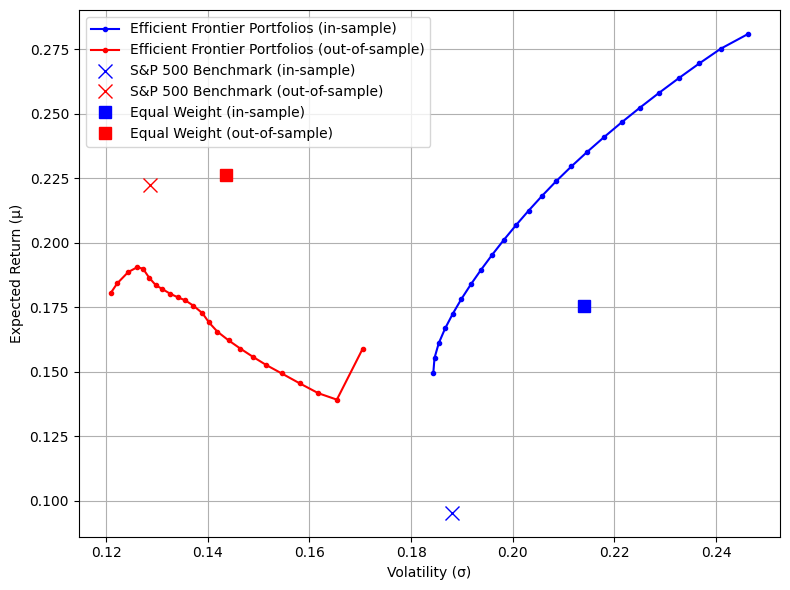

In [ ]:
# ---- Plot ----
plt.figure(figsize=(8,6))

# Efficient frontier (in-sample)
plt.plot(vols_15_22, rets_15_22, "b.-", label="Efficient Frontier Portfolios (in-sample)")

# Out-of-sample frontier
plt.plot(vols_23_24, rets_23_24, "r.-", label="Efficient Frontier Portfolios (out-of-sample)")

# Benchmarks
plt.plot(sp500_sigma_15_22, sp500_mu_15_22, "kx", color='b', markersize=10, label="S&P 500 Benchmark (in-sample)")
plt.plot(sp500_sigma_23_24, sp500_mu_23_24, "kx", color='r', markersize=10, label="S&P 500 Benchmark (out-of-sample)")

# Equal weight portfolios
plt.plot(equal_sigma_15_22, equal_mu_15_22, "bs", markersize=8, label="Equal Weight (in-sample)")
plt.plot(equal_sigma_23_24, equal_mu_23_24, "rs", markersize=8, label="Equal Weight (out-of-sample)")

# Labels and formatting
plt.xlabel("Volatility (σ)")
plt.ylabel("Expected Return (μ)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [281]:
# get number of portfolios with valid solutions
valid_portfolios = np.sum(~np.isnan(rets_15_22))

# show portfolio composition of efficient portfolio with same volatility as S&P 500
target_vol = sp500_sigma_15_22
target_weights = weights_15_22[:valid_portfolios][np.argmin(np.abs(vols_15_18[:valid_portfolios] - target_vol))]

# ---- In-Sample Performance (2015–2022) ----
print("In-sample performance (2015–2022):")

# Target Portfolio
target_return = mu_15_22 @ target_weights
target_volatility = np.sqrt(target_weights.T @ sigma_15_22.values @ target_weights)
print(f"• Target portfolio return: {target_return:.2%}")
print(f"  Target portfolio volatility: {target_volatility:.2%}")

# S&P 500 Benchmark
print(f"• S&P 500 benchmark return: {sp500_mu_15_22:.2%}")
print(f"  S&P 500 benchmark volatility: {sp500_sigma_15_22:.2%}")

# Equal Weight Portfolio
print(f"• Equal weight portfolio return: {equal_mu_15_22:.2%}")
print(f"  Equal weight portfolio volatility: {equal_sigma_15_22:.2%}")

# ---- Out-of-Sample Performance (2023–2024) ----
print("\nOut-of-sample performance (2023–2024):")

# Target Portfolio
out_of_sample_return = target_weights @ mu_23_24
out_of_sample_volatility = np.sqrt(target_weights.T @ sigma_23_24.values @ target_weights)
print(f"• Target portfolio return: {out_of_sample_return:.2%}")
print(f"  Target portfolio volatility: {out_of_sample_volatility:.2%}")

# S&P 500 Benchmark
print(f"• S&P 500 benchmark return: {sp500_mu_23_24:.2%}")
print(f"  S&P 500 benchmark volatility: {sp500_sigma_23_24:.2%}")

# Equal Weight Portfolio
print(f"• Equal weight portfolio return: {equal_mu_23_24:.2%}")
print(f"  Equal weight portfolio volatility: {equal_sigma_23_24:.2%}")


# print portfolio composition of target portfolio
print("\nPortfolio composition for target volatility (S&P 500):")
target_weights_df = pd.DataFrame({"Ticker": returns.columns,
                                  "Weight": target_weights})
target_weights_df


In-sample performance (2015–2022):
• Target portfolio return: 28.09%
  Target portfolio volatility: 24.63%
• S&P 500 benchmark return: 9.54%
  S&P 500 benchmark volatility: 18.81%
• Equal weight portfolio return: 17.54%
  Equal weight portfolio volatility: 21.40%

Out-of-sample performance (2023–2024):
• Target portfolio return: 15.89%
  Target portfolio volatility: 17.05%
• S&P 500 benchmark return: 22.24%
  S&P 500 benchmark volatility: 12.86%
• Equal weight portfolio return: 22.63%
  Equal weight portfolio volatility: 14.35%

Portfolio composition for target volatility (S&P 500):


,Ticker,Weight
0,CPAY.N,0.0100
1,O.N,0.0100
2,MKTX.OQ,0.1000
3,EG.N,0.0100
4,BKNG.OQ,0.0100
5,PAYX.OQ,0.0100
6,GL.N,0.0100
7,KKR.N,0.0100
8,VRSK.OQ,0.0100
9,MSCI.N,0.1000
